In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_excel(r"C:\Users\Rutvi\OneDrive\Desktop\Streaming Churn Intelligence Behavioral Segmentation & Retention Analytics\archive (6)\netflix_large_user_data.xlsx")

In [3]:
df.head()

,Customer ID,Subscription Length (Months),Customer Satisfaction Score (1-10),Daily Watch Time (Hours),Engagement Rate (1-10),Device Used Most Often,Genre Preference,Region,Payment History (On-Time/Delayed),Subscription Plan,Churn Status (Yes/No),Support Queries Logged,Age,Monthly Income ($),Promotional Offers Used,Number of Profiles Created
0,C00001,12,10,4.85,4,Tablet,Action,Europe,On-Time,Basic,No,10,33,6250,5,2
1,C00002,12,8,1.75,9,Laptop,Thriller,Europe,On-Time,Basic,Yes,9,28,7018,1,5
2,C00003,3,4,2.75,9,Smart TV,Comedy,Asia,On-Time,Premium,Yes,3,18,1055,1,5
3,C00004,3,7,3.00,9,Smart TV,Drama,Europe,Delayed,Premium,No,5,32,6707,5,4
4,C00005,24,2,1.37,5,Mobile,Drama,North America,On-Time,Standard,Yes,2,59,1506,3,5


In [4]:
df.shape

(1000, 16)

In [5]:
df.info()



<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Customer ID                         1000 non-null   str    
 1   Subscription Length (Months)        1000 non-null   int64  
 2   Customer Satisfaction Score (1-10)  1000 non-null   int64  
 3   Daily Watch Time (Hours)            1000 non-null   float64
 4   Engagement Rate (1-10)              1000 non-null   int64  
 5   Device Used Most Often              1000 non-null   str    
 6   Genre Preference                    1000 non-null   str    
 7   Region                              1000 non-null   str    
 8   Payment History (On-Time/Delayed)   1000 non-null   str    
 9   Subscription Plan                   1000 non-null   str    
 10  Churn Status (Yes/No)               1000 non-null   str    
 11  Support Queries Logged              1000 non-null   int

## Missing Value Analysis

We check missing values to understand data quality issues.

In [6]:
df.isnull().sum().sort_values(ascending=False)

Customer ID                           0
Subscription Length (Months)          0
Customer Satisfaction Score (1-10)    0
Daily Watch Time (Hours)              0
Engagement Rate (1-10)                0
Device Used Most Often                0
Genre Preference                      0
Region                                0
Payment History (On-Time/Delayed)     0
Subscription Plan                     0
Churn Status (Yes/No)                 0
Support Queries Logged                0
Age                                   0
Monthly Income ($)                    0
Promotional Offers Used               0
Number of Profiles Created            0
dtype: int64

In [7]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

##  Remove Duplicates

Duplicates can distort churn analysis and KPIs.

In [8]:
df.duplicated().sum()
df = df.drop_duplicates()

In [9]:
df.dtypes

Customer ID                               str
Subscription Length (Months)            int64
Customer Satisfaction Score (1-10)      int64
Daily Watch Time (Hours)              float64
Engagement Rate (1-10)                  int64
Device Used Most Often                    str
Genre Preference                          str
Region                                    str
Payment History (On-Time/Delayed)         str
Subscription Plan                         str
Churn Status (Yes/No)                     str
Support Queries Logged                  int64
Age                                     int64
Monthly Income ($)                      int64
Promotional Offers Used                 int64
Number of Profiles Created              int64
dtype: object

In [10]:
for col in df.columns:
    if 'date' in col.lower():
        df[col] = pd.to_datetime(df[col], errors='coerce')

##  Identify Target Variable (Churn)

We locate the churn column which will be used for:
- ML modeling
- Business insights

In [11]:
[col for col in df.columns if 'churn' in col.lower() or 'cancel' in col.lower() or 'active' in col.lower()]

['Churn Status (Yes/No)']

##  Churn Distribution

We analyze how many users:
- Stayed
- Churned

This gives initial business insight.

In [15]:
target_candidates = [col for col in df.columns 
                     if 'churn' in col.lower() 
                     or 'cancel' in col.lower() 
                     or 'active' in col.lower()]

target_candidates

['Churn Status (Yes/No)']

In [16]:
target_col = target_candidates[0]
df[target_col].value_counts()

Churn Status (Yes/No)
Yes    539
No     461
Name: count, dtype: int64

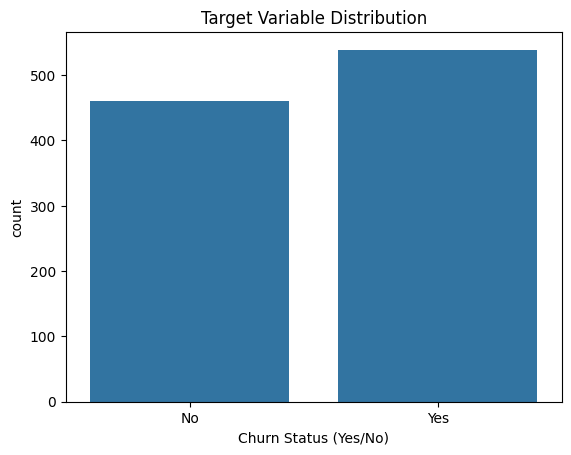

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=target_col, data=df)
plt.title("Target Variable Distribution")
plt.show()

# Final Conclusion — Notebook 01

## What We Achieved
We successfully cleaned and prepared the dataset for analysis.

---

## 📊 Key Outputs
- Missing values handled safely
- Duplicates removed
- Data types corrected
- Target column dynamically identified
- Initial target distribution analyzed

---

## 💡 Key Insight
We learned that real-world datasets:
- Do NOT have standardized column names
- Require dynamic detection logic
- Need defensive coding practices

---

